## ![](https://ga-dash.s3.amazonaws.com/production/assets/logo-9f88ae6c9c3871690e33280fcf557f33.png) Project 3: APIs, NLP, and Classification | Part 1: Cleaning Datasets

---

[README](../README.md) | **Part 1: Cleaning Datasets** | [Part 2: xxx](02_Regression.ipynb) | [Part 3: xxx](03_Interpretation.ipynb)

---

### Introduction
xxx

### Import

In [84]:
# 1. Standard Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Sklearn Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 3. NLTK Libraries
from nltk.tokenize import sent_tokenize, word_tokenize, RegexpTokenizer
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

### Load Data

In [64]:
df = pd.read_csv('../data/subreddit_pepsi_vs_cocacola.csv')

In [65]:
df.head()

,title,score,id,url,comms_num,created,body,is_pepsi
0,Wall clock.,17,1godhom,https://www.reddit.com/gallery/1godhom,1,11/11/2024 5:58,I'm trying to locate a value for this clock. I...,0
1,"Happy Veterans Day!, Coca Cola poster sealed d...",4,1gojyxe,https://i.redd.it/a3xsqwwaa70e1.jpeg,0,11/11/2024 11:31,NaN,0
2,What do yall like better,30,1go7cpq,https://www.reddit.com/gallery/1go7cpq,85,11/11/2024 1:33,Diet coke or coke and why,0
3,Every drink company cola has owned and owns an...,0,1goc0ni,https://miro.com/app/board/uXjVM_YVujs=/,1,11/11/2024 4:53,NaN,0
4,Wall thermometer,22,1gnaebp,https://i.redd.it/13cyo811rvzd1.jpeg,4,11/9/2024 20:44,Vintage wall thermometer my Dad had.,0


### Cleaning Columns

In [67]:
df.isnull().sum()

title          0
score          0
id             0
url            0
comms_num      0
created        0
body         713
is_pepsi       0
dtype: int64

In [68]:
df['title_body'] = df['title'] + ' ' + df['body']

In [69]:
df.head()

,title,score,id,url,comms_num,created,body,is_pepsi,title_body
0,Wall clock.,17,1godhom,https://www.reddit.com/gallery/1godhom,1,11/11/2024 5:58,I'm trying to locate a value for this clock. I...,0,Wall clock. I'm trying to locate a value for t...
1,"Happy Veterans Day!, Coca Cola poster sealed d...",4,1gojyxe,https://i.redd.it/a3xsqwwaa70e1.jpeg,0,11/11/2024 11:31,NaN,0,NaN
2,What do yall like better,30,1go7cpq,https://www.reddit.com/gallery/1go7cpq,85,11/11/2024 1:33,Diet coke or coke and why,0,What do yall like better Diet coke or coke and...
3,Every drink company cola has owned and owns an...,0,1goc0ni,https://miro.com/app/board/uXjVM_YVujs=/,1,11/11/2024 4:53,NaN,0,NaN
4,Wall thermometer,22,1gnaebp,https://i.redd.it/13cyo811rvzd1.jpeg,4,11/9/2024 20:44,Vintage wall thermometer my Dad had.,0,Wall thermometer Vintage wall thermometer my D...


In [70]:
df.dtypes

title         object
score          int64
id            object
url           object
comms_num      int64
created       object
body          object
is_pepsi       int64
title_body    object
dtype: object

In [90]:
df['is_pepsi'].value_counts(normalize = True)

is_pepsi
1    0.508172
0    0.491828
Name: proportion, dtype: float64

### Transformer

In [79]:
# from sklearn.base import BaseEstimator, TransformerMixin
# from nltk.tokenize import RegexpTokenizer
# from nltk.corpus import stopwords
# from nltk.stem import PorterStemmer
# import nltk

class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.tokenizer = RegexpTokenizer(r'\w+')                                     # Tokenizes words, removes punctuation
        self.stop_words = set(stopwords.words('english'))                            # Load English stopwords
        self.stemmer = PorterStemmer()                                               # Initialize PorterStemmer    
                   
    def fit(self, X, y = None):                                                      # Required by scikit-learn's API
        return self                   

    def transform(self, X):
        '''
        Transform doc in X by 
        lowering, tokenizing & removing punctuation, removing stopwords, and stemming.
        '''
        processed_docs = []
        for doc in X:
            doc = "" if doc is None else str(doc)                                    # Treat all doc as string and None as empty string
            doc = doc.lower()                                                        # Lowering
            tokens = self.tokenizer.tokenize(doc)                                    # Use tokenize method from self.tokenizer = RegexpTokenizer(r'\w+')
                                                                                     # which was first defined in __init__
            tokens = [token for token in tokens if token not in self.stop_words]     # Remove all stopwords
            tokens = [self.stemmer.stem(token) for token in tokens]                  # Stemming
            processed_docs.append(' '.join(tokens))
        return processed_docs

### Model

In [86]:
# Define the pipeline
pipeline = Pipeline([
    ('preprocessor', TextPreprocessor()),  # Custom preprocessing step
    ('vectorizer', CountVectorizer()),     # Vectorization step
    ('classifier', MultinomialNB())        # Naive Bayes classifier
])

Accuracy: 0.7278911564625851


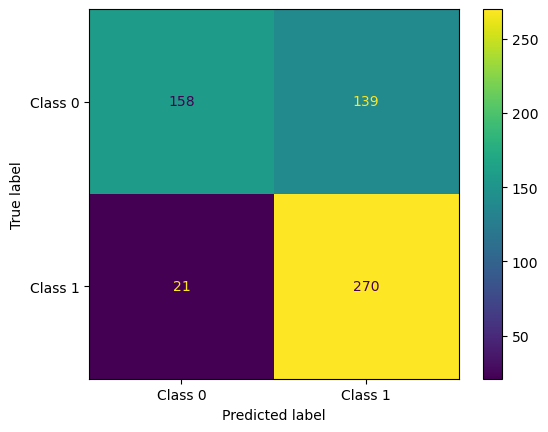

In [88]:
# Example usage with train/test split
X = df['title_body']  # Assuming 'title_body' is the column with text data
y = df['is_pepsi']  # Assuming 'target' is the column with labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit the pipeline with training data
pipeline.fit(X_train, y_train)

# Make predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot()
plt.show()

Accuracy: 0.8036496350364963


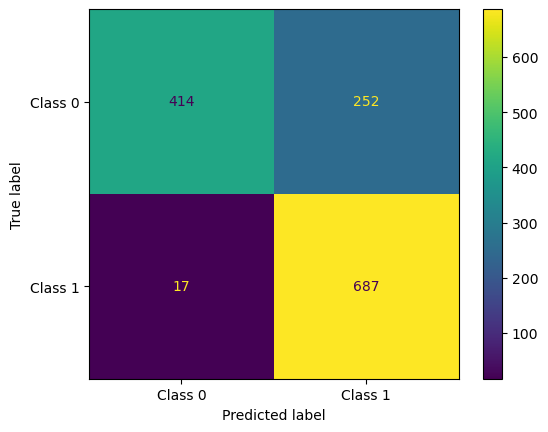

In [106]:
y_pred_train = pipeline.predict(X_train)
print(f"Accuracy: {accuracy_score(y_train, y_pred_train)}")
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot()
plt.show()

In [126]:
pipe_params = {
    'vectorizer__max_features': [2_000, 3_000, 4_000, 5_000, None]
    , 'vectorizer__min_df': [2, 3, 4, 5]
    , 'vectorizer__max_df': [.90, .95, .98]
    , 'vectorizer__ngram_range': [(1,1), (1,2), (1,3), (2,2), (2,3)]
              }

In [128]:
gs = GridSearchCV(pipeline, # what object are we optimizing?
                  param_grid = pipe_params, # what parameters values are we searching?
                  cv = 5) # 5-fold cross-validation.

In [130]:
gs.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor', TextPreprocessor()),
                                       ('vectorizer', CountVectorizer()),
                                       ('classifier', MultinomialNB())]),
             param_grid={'vectorizer__max_df': [0.9, 0.95, 0.98],
                         'vectorizer__max_features': [2000, 3000, 4000, 5000,
                                                      None],
                         'vectorizer__min_df': [2, 3, 4, 5],
                         'vectorizer__ngram_range': [(1, 1), (1, 2), (1, 3),
                                                     (2, 2), (2, 3)]})

In [124]:
gs.best_params_

{'vectorizer__max_df': 0.9,
 'vectorizer__max_features': 2000,
 'vectorizer__min_df': 2,
 'vectorizer__ngram_range': (1, 2)}

In [122]:
gs.best_score_, gs.score(X_train, y_train), gs.score(X_test, y_test)

(0.7496350364963502, 0.7941605839416058, 0.7346938775510204)

In [ ]:
CountVectorizer()

In [94]:
tp = TextPreprocessor()